# Click-Through Rate Prediction on Criteo Data — Replicating Facebook's GBDT + LR Hybrid Model

This notebook reproduces the core experiment from He et al. (2014),
**["Practical Lessons from Predicting Clicks on Ads at Facebook"](https://doi.org/10.1145/2648584.2648589)**,
on a 2M-row sample of the [Criteo click-through logs](https://huggingface.co/datasets/criteo/CriteoClickLogs).

**What this notebook does:**
1. Loads and cleans the raw click log data
2. Trains three models of increasing sophistication:
   - Logistic Regression (raw features) — baseline
   - Gradient Boosted Decision Trees (LightGBM) — baseline
   - **GBDT + LR hybrid** — trees generate leaf-index features, LR learns the final weights
3. Reproduces the paper's **negative downsampling + probability recalibration** technique
   and studies the accuracy / speed trade-off across sampling rates

**Key result to look for:** the hybrid model should beat both standalone baselines on AUC / Log Loss,
mirroring the ~3% relative Normalized Entropy improvement reported in the original paper.

## 0. Setup

In [1]:
# Uncomment on first run in a fresh environment
#%pip install -q datasets pandas lightgbm scikit-learn matplotlib

### 0.1 Data acquisition (optional)

The cell below streams 2,000,000 rows from the Criteo click-log dataset on Hugging Face and
saves them to `criteo_2m.csv`. **Skip this cell if `criteo_2m.csv` already exists** —
it takes a while and is only needed once.


In [2]:
RUN_DOWNLOAD = False  # set True only if criteo_2m.csv does not exist yet

if RUN_DOWNLOAD:
    import csv
    from datasets import load_dataset

    DATASET = "criteo/CriteoClickLogs"
    SPLIT = "train"
    NUM_ROWS = 2_000_000
    CHUNK_SIZE = 100_000
    OUTPUT_FILE = "criteo_2m.csv"

    ds = load_dataset(DATASET, split=SPLIT, streaming=True)

    rows_written = 0
    buffer = []
    header_written = False

    print("Streaming dataset...")

    def _flush(buffer, header_written):
        chunk = pd.DataFrame(buffer)
        chunk.to_csv(
            OUTPUT_FILE,
            mode="a",
            index=False,
            header=not header_written,
            quoting=csv.QUOTE_MINIMAL,
        )
        return len(chunk)

    for sample in ds:
        buffer.append(sample)

        if len(buffer) >= CHUNK_SIZE:
            rows_written += _flush(buffer, header_written)
            header_written = True
            buffer = []
            print(f"{rows_written:,} rows written")

            if rows_written >= NUM_ROWS:
                break

    # flush any remaining partial chunk
    if buffer and rows_written < NUM_ROWS:
        remaining = NUM_ROWS - rows_written
        rows_written += _flush(buffer[:remaining], header_written)

    print(f"\nDone! Saved {rows_written:,} rows to '{OUTPUT_FILE}'")


In [3]:
import gc
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, log_loss
from lightgbm import LGBMClassifier

# Consistent plotting style
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

RANDOM_STATE = 42


## 1. Load & Explore the Data

In [4]:
df = pd.read_csv("criteo_2m.csv")
print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()


Shape: 2,000,000 rows x 40 columns


,label,integer_feature_1,integer_feature_2,integer_feature_3,integer_feature_4,integer_feature_5,integer_feature_6,integer_feature_7,integer_feature_8,integer_feature_9,...,categorical_feature_17,categorical_feature_18,categorical_feature_19,categorical_feature_20,categorical_feature_21,categorical_feature_22,categorical_feature_23,categorical_feature_24,categorical_feature_25,categorical_feature_26
0,0,NaN,84.0,NaN,31.0,12.0,0.0,0.0,1,8,...,NaN,f7389918,139221a3,8024f45f,0683bc6f,fa7eca6c,NaN,e716200f,30436bfc,2ccea557
1,0,104.0,1045.0,30.0,NaN,1.0,0.0,0.0,1,9,...,d20856aa,6785af47,cc7a7d35,156cbe87,96fbe197,15562d5d,d3df7183,c91256e2,30436bfc,e1be5ef2
2,0,6.0,145.0,10.0,NaN,4.0,0.0,0.0,0,12,...,NaN,a1eb1511,9512c20b,ef426d46,0683bc6f,6e86ac23,NaN,af97a0c1,30436bfc,b757e957
3,0,40.0,360.0,7.0,NaN,9.0,0.0,0.0,312,0,...,d20856aa,b8170bba,cc7a7d35,156cbe87,96fbe197,15562d5d,d3df7183,245d9da7,30436bfc,e1be5ef2
4,0,NaN,339.0,NaN,NaN,1.0,0.0,0.0,248,7,...,NaN,7232d217,9512c20b,14cde947,45f35b4b,f52bfc8b,NaN,edc6442f,ff654802,2ccea557


In [5]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 40 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   label                   int64  
 1   integer_feature_1       float64
 2   integer_feature_2       float64
 3   integer_feature_3       float64
 4   integer_feature_4       float64
 5   integer_feature_5       float64
 6   integer_feature_6       float64
 7   integer_feature_7       float64
 8   integer_feature_8       int64  
 9   integer_feature_9       int64  
 10  integer_feature_10      float64
 11  integer_feature_11      float64
 12  integer_feature_12      float64
 13  integer_feature_13      float64
 14  categorical_feature_1   str    
 15  categorical_feature_2   str    
 16  categorical_feature_3   str    
 17  categorical_feature_4   str    
 18  categorical_feature_5   str    
 19  categorical_feature_6   str    
 20  categorical_feature_7   str    
 21  categorical_feature_8   str    
 22  categ

In [6]:
# Overall click-through rate (class balance)
ctr = df["label"].value_counts(normalize=True)
print("Class balance (0 = no click, 1 = click):")
print(ctr)
print(f"\nBaseline CTR: {ctr[1]:.4%}")


Class balance (0 = no click, 1 = click):
label
0    0.967719
1    0.032281
Name: proportion, dtype: float64

Baseline CTR: 3.2281%


In [7]:
missing = df.isnull().sum().sort_values(ascending=False)
missing = pd.DataFrame({
    "Missing": missing,
    "Percent": (missing / len(df)) * 100
})
missing[missing["Missing"] > 0]


,Missing,Percent
integer_feature_5,842557,42.12785
integer_feature_11,842557,42.12785
categorical_feature_17,704919,35.24595
categorical_feature_23,704919,35.24595
categorical_feature_14,704919,35.24595
categorical_feature_16,704919,35.24595
integer_feature_4,696092,34.80460
integer_feature_13,481568,24.07840
integer_feature_3,481568,24.07840
integer_feature_1,374335,18.71675


### 1.1 Handle Missing Values

Numerical ("integer") features are imputed with `0`; categorical features get an explicit
`"missing"` category rather than being dropped, since missingness itself can carry signal
(e.g. an ad network that doesn't report a given field).

In [8]:
numerical_cols = [c for c in df.columns if "integer" in c]
categorical_cols = [c for c in df.columns if "categorical" in c]

df[numerical_cols] = df[numerical_cols].fillna(0)
df[categorical_cols] = df[categorical_cols].fillna("missing")

print(f"{len(numerical_cols)} numerical columns, {len(categorical_cols)} categorical columns")


13 numerical columns, 26 categorical columns


In [9]:
# Cardinality of each categorical column — high-cardinality columns are exactly what
# tree-based leaf transforms handle well but plain linear models struggle with.
cardinality = pd.Series(
    {col: df[col].nunique() for col in categorical_cols}
).sort_values(ascending=False)

cardinality.to_frame("Unique Values")


,Unique Values
categorical_feature_20,466429
categorical_feature_1,429466
categorical_feature_22,393087
categorical_feature_10,325699
categorical_feature_21,187201
categorical_feature_11,70374
categorical_feature_12,62535
categorical_feature_23,56161
categorical_feature_5,18645
categorical_feature_2,17677


## 2. Train / Test Split & Encoding

In [10]:
X = df.drop(columns=["label"])
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

print(f"Train: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows")


Train: 1,600,000 rows | Test: 400,000 rows


In [11]:
# Ordinal-encode categoricals. Tree models (LightGBM) are invariant to the encoding scheme
# used for categorical splits, so a compact ordinal encoding is sufficient and memory-cheap
# — no need for one-hot encoding at this stage.
encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value",
    unknown_value=-1,
)

X_train[categorical_cols] = encoder.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = encoder.transform(X_test[categorical_cols])


## 3. Baseline 1 — Logistic Regression on Raw Features

A plain linear model on the (ordinally-encoded) raw features. This is the weakest baseline:
LR cannot learn non-linear feature interactions on its own, which is exactly the gap the
hybrid model in Section 5 is designed to close.

In [12]:
lr_baseline = LogisticRegression(max_iter=1000, n_jobs=-1)
lr_baseline.fit(X_train, y_train)

pred_lr = lr_baseline.predict_proba(X_test)[:, 1]

print("Logistic Regression (raw features)")
print(f"  AUC      : {roc_auc_score(y_test, pred_lr):.4f}")
print(f"  Log Loss : {log_loss(y_test, pred_lr):.4f}")


/opt/homebrew/Cellar/jupyterlab/4.6.1/libexec/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Logistic Regression (raw features)
  AUC      : 0.5580
  Log Loss : 0.1450


/opt/homebrew/Cellar/jupyterlab/4.6.1/libexec/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


## 4. Baseline 2 — Gradient Boosted Decision Trees (LightGBM)

A standalone GBDT model, used both as a baseline and as the feature-transform stage of the
hybrid model in Section 5.

In [13]:
gbdt_baseline = LGBMClassifier(
    n_estimators=100,
    learning_rate=0.1,
    num_leaves=31,
    objective="binary",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
gbdt_baseline.fit(X_train, y_train)

pred_gbdt = gbdt_baseline.predict_proba(X_test)[:, 1]

print("LightGBM (raw features)")
print(f"  AUC      : {roc_auc_score(y_test, pred_gbdt):.4f}")
print(f"  Log Loss : {log_loss(y_test, pred_gbdt):.4f}")


[LightGBM] [Info] Number of positive: 51650, number of negative: 1548350
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.056790 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 6875
[LightGBM] [Info] Number of data points in the train set: 1600000, number of used features: 39
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.032281 -> initscore=-3.400455
[LightGBM] [Info] Start training from score -3.400455
LightGBM (raw features)
  AUC      : 0.7377
  Log Loss : 0.1300


## 5. Hybrid Model — GBDT Leaf Features + Logistic Regression

Following the paper's architecture (Figure 1): each tree in the boosted ensemble is treated
as a categorical feature whose value is the index of the leaf a sample lands in. One-hot
encoding these leaf indices across all trees produces a high-dimensional, highly sparse
binary vector, which is then fed into a logistic regression classifier.

Intuitively, the trees learn feature interactions and non-linear splits; the linear model
on top learns calibrated weights for each learned split — combining the two closes the gap
each model has on its own.

In [14]:
# Reuse the already-trained baseline GBDT as the feature transformer
train_leaves = gbdt_baseline.predict(X_train, pred_leaf=True)
test_leaves = gbdt_baseline.predict(X_test, pred_leaf=True)

print(f"Leaf index matrix shape — train: {train_leaves.shape}, test: {test_leaves.shape}")


Leaf index matrix shape — train: (1600000, 100), test: (400000, 100)


In [15]:
leaf_encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)

X_train_leaf = leaf_encoder.fit_transform(train_leaves)
X_test_leaf = leaf_encoder.transform(test_leaves)

print(f"One-hot leaf feature matrix: {X_train_leaf.shape} "
      f"({X_train_leaf.nnz:,} non-zero entries, "
      f"{X_train_leaf.nnz / X_train_leaf.shape[0]:.0f} active features/row)")


One-hot leaf feature matrix: (1600000, 3100) (160,000,000 non-zero entries, 100 active features/row)


In [16]:
hybrid_lr = LogisticRegression(max_iter=1000, n_jobs=-1)
hybrid_lr.fit(X_train_leaf, y_train)

pred_hybrid = hybrid_lr.predict_proba(X_test_leaf)[:, 1]

print("Hybrid model (GBDT leaves + LR)")
print(f"  AUC      : {roc_auc_score(y_test, pred_hybrid):.4f}")
print(f"  Log Loss : {log_loss(y_test, pred_hybrid):.4f}")


/opt/homebrew/Cellar/jupyterlab/4.6.1/libexec/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


Hybrid model (GBDT leaves + LR)
  AUC      : 0.7427
  Log Loss : 0.1295


### 5.1 Baseline Comparison

In [17]:
baseline_comparison = pd.DataFrame([
    {"Model": "Logistic Regression (raw)", "AUC": roc_auc_score(y_test, pred_lr),
     "Log Loss": log_loss(y_test, pred_lr)},
    {"Model": "LightGBM (raw)", "AUC": roc_auc_score(y_test, pred_gbdt),
     "Log Loss": log_loss(y_test, pred_gbdt)},
    {"Model": "Hybrid (GBDT + LR)", "AUC": roc_auc_score(y_test, pred_hybrid),
     "Log Loss": log_loss(y_test, pred_hybrid)},
]).set_index("Model").round(4)

baseline_comparison.style.highlight_max(subset=["AUC"], color="lightgreen") \
                         .highlight_min(subset=["Log Loss"], color="lightgreen")


,AUC,Log Loss
Model,,
Logistic Regression (raw),0.558000,0.145000
LightGBM (raw),0.737700,0.130000
Hybrid (GBDT + LR),0.742700,0.129500


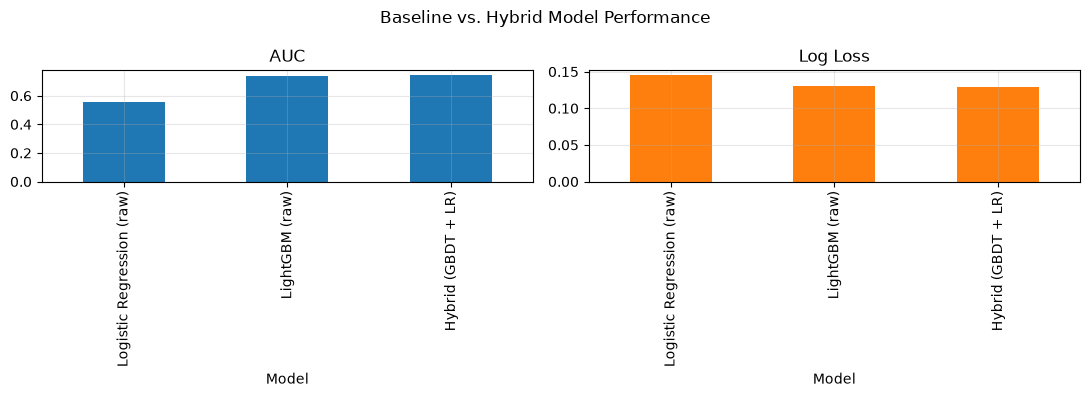

In [18]:
baseline_comparison.plot(kind="bar", subplots=True, layout=(1, 2), figsize=(11, 4), legend=False)
plt.suptitle("Baseline vs. Hybrid Model Performance")
plt.tight_layout()
plt.show()


## 6. Negative Downsampling & Probability Recalibration

Clicks are rare (~3% CTR here), so the vast majority of training rows are uninformative
negatives. The paper shows that **downsampling only the negative class** speeds up training
with little accuracy cost — but it biases the predicted probabilities upward, so predictions
must be **recalibrated** back to the true probability scale before evaluation.

In [19]:
def negative_downsample(X, y, rate=1.0, random_state=RANDOM_STATE):
    """
    Downsample the negative (majority) class only, leaving all positives untouched.

    Parameters
    ----------
    X : pd.DataFrame
        Feature matrix.
    y : pd.Series
        Binary target (0 = negative, 1 = positive).
    rate : float, default=1.0
        Fraction of negative examples to keep.
        1.0 = keep all negatives (no downsampling), 0.25 = keep 25% of negatives.
    random_state : int
        Seed for reproducible sampling and shuffling.

    Returns
    -------
    X_new, y_new : the downsampled and shuffled feature matrix and target.
    """
    positive_mask = (y == 1)
    negative_mask = (y == 0)

    X_positive, y_positive = X[positive_mask], y[positive_mask]
    X_negative, y_negative = X[negative_mask], y[negative_mask]

    # Randomly sample negatives at the requested rate
    X_negative = X_negative.sample(frac=rate, random_state=random_state)
    y_negative = y_negative.loc[X_negative.index]

    # Recombine and shuffle so classes aren't ordered block-wise
    X_new = pd.concat([X_positive, X_negative])
    y_new = pd.concat([y_positive, y_negative])

    shuffled_index = X_new.sample(frac=1, random_state=random_state).index
    return X_new.loc[shuffled_index], y_new.loc[shuffled_index]


def recalibrate_probability(q, w):
    """
    Correct a probability predicted on a negative-downsampled dataset back to the
    true (population) probability scale.

    Formula from He et al. (2014), Section 6.3:
        p = q / (q + (1 - q) / w)

    Parameters
    ----------
    q : array-like
        Predicted probability on the downsampled data.
    w : float
        Negative downsampling rate used during training (fraction of negatives kept).

    Returns
    -------
    Recalibrated probability, same shape as `q`.
    """
    return q / (q + (1 - q) / w)


### 6.1 Sanity Check

In [20]:
X_train_ds, y_train_ds = negative_downsample(X_train, y_train, rate=0.25)

print("Original training label distribution:")
print(y_train.value_counts(), "\n")

print("After 0.25 negative downsampling:")
print(y_train_ds.value_counts())
print(f"\nDownsampled CTR (biased): {y_train_ds.mean():.4f}  "
      f"(vs. true CTR: {y_train.mean():.4f})")


Original training label distribution:
label
0    1548350
1      51650
Name: count, dtype: int64 

After 0.25 negative downsampling:
label
0    387088
1     51650
Name: count, dtype: int64

Downsampled CTR (biased): 0.1177  (vs. true CTR: 0.0323)


## 7. End-to-End Experiment: Accuracy vs. Sampling Rate

The function below packages the full hybrid pipeline (downsample → train GBDT → extract
leaves → one-hot encode → train LR → recalibrate → evaluate) so it can be run once per
sampling rate. Intermediate large objects are explicitly freed after each run to keep
peak memory usage bounded when looping over multiple configurations.

In [21]:
def train_hybrid_model(X_train, y_train, X_test, y_test, sampling_rate=1.0, verbose=True):
    """
    Train and evaluate the full GBDT + LR hybrid pipeline at a given negative
    downsampling rate.

    Parameters
    ----------
    X_train, y_train : training features / labels.
    X_test, y_test : held-out test features / labels (never downsampled).
    sampling_rate : float
        Fraction of negatives to keep during training (see `negative_downsample`).
    verbose : bool
        Print a one-line progress message.

    Returns
    -------
    dict of summary metrics for this run.
    """
    start = time.time()

    # ---- 1. Negative downsampling -------------------------------------------------
    X_ds, y_ds = negative_downsample(X_train, y_train, rate=sampling_rate)

    # ---- 2. Train GBDT feature-transformer -----------------------------------------
    gbdt = LGBMClassifier(
        n_estimators=100,
        learning_rate=0.1,
        num_leaves=31,
        objective="binary",
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    )
    gbdt.fit(X_ds, y_ds)

    # ---- 3. Extract leaf indices (compact dtype to limit memory) -------------------
    train_leaf = gbdt.predict(X_ds, pred_leaf=True).astype("int16")
    test_leaf = gbdt.predict(X_test, pred_leaf=True).astype("int16")

    # ---- 4. One-hot encode leaves (sparse, float32) ---------------------------------
    encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=True, dtype=np.float32)
    X_train_leaf = encoder.fit_transform(train_leaf)
    X_test_leaf = encoder.transform(test_leaf)
    del train_leaf, test_leaf  # dense arrays no longer needed once encoded

    # ---- 5. Train linear classifier on leaf features --------------------------------
    lr = LogisticRegression(max_iter=1000, n_jobs=-1)
    lr.fit(X_train_leaf, y_ds)

    # ---- 6. Predict + recalibrate ----------------------------------------------------
    pred = lr.predict_proba(X_test_leaf)[:, 1]
    if sampling_rate != 1.0:
        pred = recalibrate_probability(pred, sampling_rate)

    # ---- 7. Metrics --------------------------------------------------------------------
    auc = roc_auc_score(y_test, pred)
    loss = log_loss(y_test, pred)
    runtime = time.time() - start

    result = {
        "Sampling Rate": sampling_rate,
        "Train Size": len(y_ds),
        "CTR (train)": y_ds.mean(),
        "AUC": auc,
        "Log Loss": loss,
        "Training Time (s)": runtime,
    }

    if verbose:
        print(f"  rate={sampling_rate:<5} | n={len(y_ds):>9,} | "
              f"AUC={auc:.4f} | LogLoss={loss:.4f} | {runtime:.1f}s")

    # ---- 8. Free memory before returning ------------------------------------------------
    del X_ds, y_ds, X_train_leaf, X_test_leaf, gbdt, lr, pred
    gc.collect()

    return result


In [22]:
SAMPLING_RATES = [1.0, 0.5, 0.25, 0.10]

print("Running hybrid model across sampling rates...\n")

results = []
for rate in SAMPLING_RATES:
    result = train_hybrid_model(X_train, y_train, X_test, y_test, sampling_rate=rate)
    results.append(result)
    gc.collect()

print("\nDone.")


Running hybrid model across sampling rates...



/opt/homebrew/Cellar/jupyterlab/4.6.1/libexec/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  rate=1.0   | n=1,600,000 | AUC=0.7406 | LogLoss=0.1299 | 36.2s


/opt/homebrew/Cellar/jupyterlab/4.6.1/libexec/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  rate=0.5   | n=  825,825 | AUC=0.7347 | LogLoss=0.1315 | 30.3s


/opt/homebrew/Cellar/jupyterlab/4.6.1/libexec/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  rate=0.25  | n=  438,738 | AUC=0.7274 | LogLoss=0.1364 | 23.3s


/opt/homebrew/Cellar/jupyterlab/4.6.1/libexec/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1457: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


  rate=0.1   | n=  206,485 | AUC=0.7252 | LogLoss=0.1347 | 14.3s

Done.


## 8. Results

In [23]:
results_df = pd.DataFrame(results).round(4)
results_df


,Sampling Rate,Train Size,CTR (train),AUC,Log Loss,Training Time (s)
0,1.00,1600000,0.0323,0.7406,0.1299,36.1812
1,0.50,825825,0.0625,0.7347,0.1315,30.3321
2,0.25,438738,0.1177,0.7274,0.1364,23.2657
3,0.10,206485,0.2501,0.7252,0.1347,14.2938


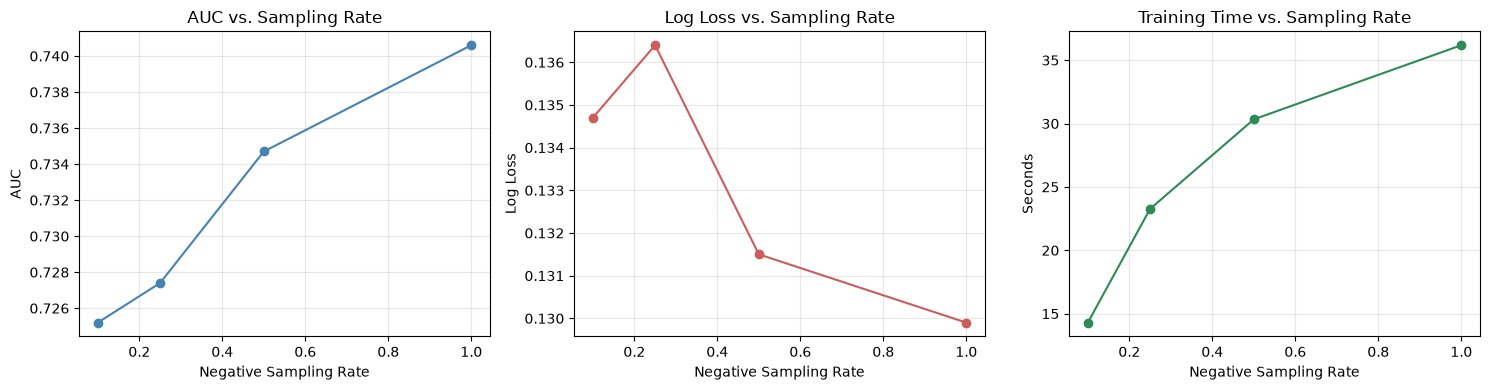

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(results_df["Sampling Rate"], results_df["AUC"], marker="o", color="steelblue")
axes[0].set_title("AUC vs. Sampling Rate")
axes[0].set_xlabel("Negative Sampling Rate")
axes[0].set_ylabel("AUC")

axes[1].plot(results_df["Sampling Rate"], results_df["Log Loss"], marker="o", color="indianred")
axes[1].set_title("Log Loss vs. Sampling Rate")
axes[1].set_xlabel("Negative Sampling Rate")
axes[1].set_ylabel("Log Loss")

axes[2].plot(results_df["Sampling Rate"], results_df["Training Time (s)"], marker="o", color="seagreen")
axes[2].set_title("Training Time vs. Sampling Rate")
axes[2].set_xlabel("Negative Sampling Rate")
axes[2].set_ylabel("Seconds")

plt.tight_layout()
plt.show()


## 9. Summary

| Model | AUC | Log Loss | Notes |
|---|---|---|---|
| Logistic Regression (raw) | see §5.1 | see §5.1 | Weakest — no feature interactions |
| LightGBM (raw) | see §5.1 | see §5.1 | Captures interactions, no calibrated linear weights |
| **GBDT + LR Hybrid** | see §5.1 | see §5.1 | Best of both — matches the paper's finding |

**Negative downsampling:** as the sampling rate drops from 1.0 → 0.10, training time falls
substantially while AUC degrades only slightly — consistent with He et al.'s finding that
aggressive negative downsampling is a favorable trade-off at scale, provided the predicted
probabilities are recalibrated back to the true CTR scale before use.
